In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import random
from torch.optim import LBFGS
from tqdm import tqdm

import os
import sys
current_dir = os.path.abspath('')
grandparent_dir = os.path.dirname(os.path.dirname(current_dir))
if grandparent_dir not in sys.path:
    sys.path.append(grandparent_dir)

from util import (
    get_data,
    get_n_params,
    get_pseudo_spacetime_cross_center_index,
    make_pseudo_spacetime_cross_offsets,
    ModelTimeRecorder,
    RelativeL2ConvergenceTracker,
)
from model.CaPITN import CaPITN


if not os.path.exists('results'):
    os.makedirs('results')

In [2]:
seed = 0
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

space_dim = 1
num_space = 3
space_step = 1e-2
num_step = 5
step_size = 1e-4

num_spatial_tokens = 1 + space_dim * (num_space - 1)
spatial_radius = (num_space // 2) * space_step
c_max = spatial_radius / step_size
center_index = get_pseudo_spacetime_cross_center_index(
    space_dim,
    num_space=num_space,
    num_step=num_step,
)

patch_offsets = torch.as_tensor(
    make_pseudo_spacetime_cross_offsets(
        space_dim,
        num_space=num_space,
        space_step=space_step,
        num_step=num_step,
        step=step_size,
    ),
    dtype=torch.float32,
    device=device,
)
assert patch_offsets.shape == (num_step * num_spatial_tokens, space_dim + 1)
assert torch.equal(
    patch_offsets[center_index],
    torch.zeros(space_dim + 1, dtype=torch.float32, device=device),
)

In [3]:
res, b_left, b_right, b_upper, b_lower = get_data([0, 2 * np.pi], [0, 1], 51, 51)
res_test, _, _, _, _ = get_data([0, 2 * np.pi], [0, 1], 101, 101)


def build_center(coords, requires_grad=True):
    center = torch.tensor(
        coords[:, None, :],
        dtype=torch.float32,
        device=device,
        requires_grad=requires_grad,
    )
    assert center.shape == (coords.shape[0], 1, space_dim + 1)
    assert center.is_leaf
    assert center.requires_grad == requires_grad
    return center


res = build_center(res)
b_left = build_center(b_left)
b_right = build_center(b_right)
b_upper = build_center(b_upper)
b_lower = build_center(b_lower)

x_res, t_res = res[:, :, 0:1], res[:, :, 1:2]
x_left, t_left = b_left[:, :, 0:1], b_left[:, :, 1:2]
x_right, t_right = b_right[:, :, 0:1], b_right[:, :, 1:2]
x_upper, t_upper = b_upper[:, :, 0:1], b_upper[:, :, 1:2]
x_lower, t_lower = b_lower[:, :, 0:1], b_lower[:, :, 1:2]


def rigid_patch_grad(value, coordinate_patch):
    token_grad = torch.autograd.grad(
        value,
        coordinate_patch,
        grad_outputs=torch.ones_like(value),
        retain_graph=True,
        create_graph=True,
    )[0]
    return token_grad.sum(dim=1)


def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight)
        m.bias.data.fill_(0.01)

In [4]:
model = CaPITN(
    in_dim=2,
    d_model=32,
    n_heads=2,
    d_ff=512,
    n_layers=1,
    out_dim=1,
    c_max=c_max,
).to(device)

model.apply(init_weights)
trainable_parameters = tuple(model.parameters())
optim = LBFGS(trainable_parameters, line_search_fn='strong_wolfe')

print(model)
print(get_n_params(model))

CaPITN(
  (embedding): Linear(in_features=2, out_features=32, bias=True)
  (encoder): Encoder(
    (layers): ModuleList(
      (0): EncoderLayer(
        (attn): CharacteristicAwareAttention(
          (W_q): Linear(in_features=32, out_features=32, bias=True)
          (W_k): Linear(in_features=32, out_features=32, bias=True)
          (W_v): Linear(in_features=32, out_features=32, bias=True)
          (W_o): Linear(in_features=32, out_features=32, bias=True)
          (dropout): Dropout(p=0.0, inplace=False)
        )
        (ffn): Sequential(
          (0): Linear(in_features=32, out_features=256, bias=True)
          (1): WaveBiasAct()
          (2): Linear(in_features=256, out_features=32, bias=True)
        )
      )
    )
  )
  (decoder): Decoder(
    (layers): ModuleList(
      (0): DecoderLayer(
        (attn): CharacteristicAwareAttention(
          (W_q): Linear(in_features=32, out_features=32, bias=True)
          (W_k): Linear(in_features=32, out_features=32, bias=True)
  

In [5]:
relative_l2_threshold = 0.1
monitor_u = np.exp(-(res_test[:, 0] - np.pi) ** 2 / (2 * (np.pi / 4) ** 2))
monitor_reference = (
    monitor_u * np.exp(5 * res_test[:, 1])
    / (monitor_u * np.exp(5 * res_test[:, 1]) + 1 - monitor_u)
).reshape(-1, 1)

def get_monitor_prediction():
    monitor_center = build_center(res_test)
    monitor_x = monitor_center[:, :, 0:1]
    monitor_t = monitor_center[:, :, 1:2]
    with torch.no_grad():
        prediction = model(monitor_x, monitor_t, patch_offsets)[:, 0, :]
    return prediction.reshape(-1, 1).cpu().numpy()

convergence_tracker = RelativeL2ConvergenceTracker(
    monitor_reference,
    relative_l2_threshold,
)
convergence_tracker.record(0.0, get_monitor_prediction())


0.6673823302509108

In [ ]:
time_recorder = ModelTimeRecorder(device)
loss_track = []

for i in tqdm(range(500)):
    def closure():
        optim.zero_grad(set_to_none=True)

        u_res = model(x_res, t_res, patch_offsets)[:, 0, :]
        u_initial = model(x_left, t_left, patch_offsets)[:, 0, :]
        u_upper = model(x_upper, t_upper, patch_offsets)[:, 0, :]
        u_lower = model(x_lower, t_lower, patch_offsets)[:, 0, :]

        u_t = rigid_patch_grad(u_res, t_res)

        loss_res = torch.mean((u_t - 5 * u_res * (1 - u_res)) ** 2)
        loss_bc = torch.mean((u_upper - u_lower) ** 2)
        x_initial = x_left[:, 0, :]
        target_initial = torch.exp(
            -(x_initial - torch.pi) ** 2 / (2 * (torch.pi / 4) ** 2)
        )
        loss_ic = torch.mean((u_initial - target_initial) ** 2)

        loss = loss_res + loss_bc + loss_ic
        if not torch.isfinite(loss):
            raise RuntimeError('Non-finite loss encountered during LBFGS closure')

        loss_track.append([loss_res.item(), loss_bc.item(), loss_ic.item()])

        loss.backward(inputs=trainable_parameters)
        return loss

    with time_recorder.record_training():
        optim.step(closure)

    convergence_tracker.record(
        time_recorder.training_time,
        get_monitor_prediction(),
    )

100%|██████████| 500/500 [04:27<00:00,  1.87it/s]


In [7]:
np.save('./results/1dreaction_loss_CaPITN.npy', loss_track)
torch.save(model.state_dict(), './results/1dreaction_CaPITN.pt')

print('Loss Res: {:4f}, Loss_BC: {:4f}, Loss_IC: {:4f}'.format(loss_track[-1][0], loss_track[-1][1], loss_track[-1][2]))
print('Train Loss: {:4f}'.format(np.sum(loss_track[-1])))

print('Training Time: {:.2f} s'.format(time_recorder.training_time))

np.save(
    './results/1dreaction_relative_l2_error_vs_training_time_CaPITN.npy',
    convergence_tracker.as_array(),
)
if convergence_tracker.first_threshold_time is None:
    print('Relative L2 threshold {:.3f} was not reached.'.format(relative_l2_threshold))
else:
    print(
        'Relative L2 threshold {:.3f} first reached at {:.6f} s'.format(
            relative_l2_threshold,
            convergence_tracker.first_threshold_time,
        )
    )


Loss Res: 0.000003, Loss_BC: 0.000000, Loss_IC: 0.000003
Train Loss: 0.000006
Training Time: 263.07 s
Relative L2 threshold 0.100 first reached at 91.746701 s


Inference Time: 0.007799 s
relative L1 error: 0.021472
relative L2 error: 0.039736


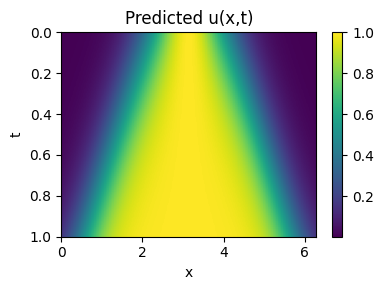

In [8]:
res_test = build_center(res_test, requires_grad=False)
x_test, t_test = res_test[:, :, 0:1], res_test[:, :, 1:2]

with time_recorder.record_inference():
    with torch.no_grad():
        pred = model(x_test, t_test, patch_offsets)[:, 0, :]
        pred = pred.cpu().numpy()
print('Inference Time: {:.6f} s'.format(time_recorder.inference_time))

pred = pred.reshape(101, 101)


def h(x):
    return np.exp(-(x - np.pi) ** 2 / (2 * (np.pi / 4) ** 2))


def u_ana(x, t):
    return h(x) * np.exp(5 * t) / (h(x) * np.exp(5 * t) + 1 - h(x))


res_test, _, _, _, _ = get_data([0, 2 * np.pi], [0, 1], 101, 101)
u = u_ana(res_test[:, 0], res_test[:, 1]).reshape(101, 101)

rl1 = np.sum(np.abs(u - pred)) / np.sum(np.abs(u))
rl2 = np.sqrt(np.sum((u - pred) ** 2) / np.sum(u ** 2))

print('relative L1 error: {:4f}'.format(rl1))
print('relative L2 error: {:4f}'.format(rl2))

plt.figure(figsize=(4, 3))
plt.imshow(pred, extent=[0, np.pi * 2, 1, 0], aspect='auto')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Predicted u(x,t)')
plt.colorbar()
plt.tight_layout()
plt.savefig('./results/1dreaction_CaPITN_pred.png')
plt.show()

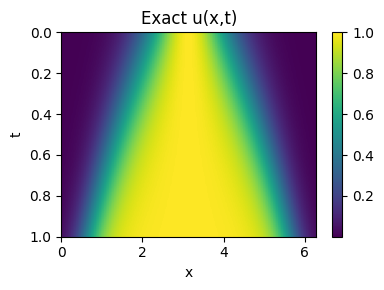

In [9]:
plt.figure(figsize=(4,3))
plt.imshow(u, extent=[0,np.pi*2,1,0], aspect='auto')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Exact u(x,t)')
plt.colorbar()
plt.tight_layout()
plt.savefig('./results/1dreaction_exact.png')
plt.show()

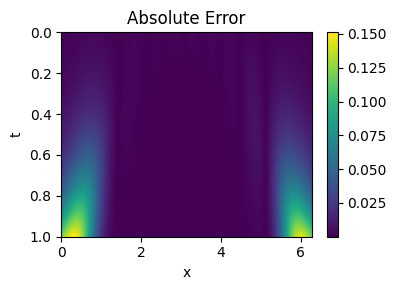

In [10]:
plt.figure(figsize=(4,3))
plt.imshow(np.abs(pred - u), extent=[0,np.pi*2,1,0], aspect='auto')
plt.xlabel('x')
plt.ylabel('t')
plt.title('Absolute Error')
plt.colorbar()
plt.tight_layout()
plt.savefig('./results/1dreaction_CaPITN_error.png')
plt.show()